##Name: Sudarsan Bista
##Student ID: 2419102
##Worksheet 6

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, UnidentifiedImageError

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Extract ZIP File

In [ ]:
import zipfile
import os

zip_path = '/content/drive/MyDrive/FruitInAmazon/FruitinAmazon.zip'
extract_path = '/content/drive/MyDrive/FruitInAmazon/FruitAmazon_extracted'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Extraction Done")

Extraction Done


# Define Dataset Path

In [ ]:
train_dir = os.path.join(extract_path, "train")

# Read Class Names

In [ ]:
import os


train_dir = os.path.join(extract_path, "FruitinAmazon", "train")

class_names = os.listdir(train_dir)
print("Classes:", class_names)

Classes: ['pupunha', 'acai', 'guarana', 'graviola', 'tucuma', 'cupuacu']


# Check Corrupted Images

In [ ]:
from PIL import Image

corrupted = []

for cls in class_names:
    path = os.path.join(train_dir, cls)

    for img_name in os.listdir(path):
        img_path = os.path.join(path, img_name)

        try:
            img = Image.open(img_path)
            img.verify()
        except:
            corrupted.append(img_path)

print("Corrupted Images:", len(corrupted))

Corrupted Images: 0


# Class Distribution

In [ ]:
class_count = {}

for cls in class_names:
    path = os.path.join(train_dir, cls)
    class_count[cls] = len(os.listdir(path))

print(class_count)

{'pupunha': 15, 'acai': 15, 'guarana': 15, 'graviola': 15, 'tucuma': 15, 'cupuacu': 15}


# Show Random Images

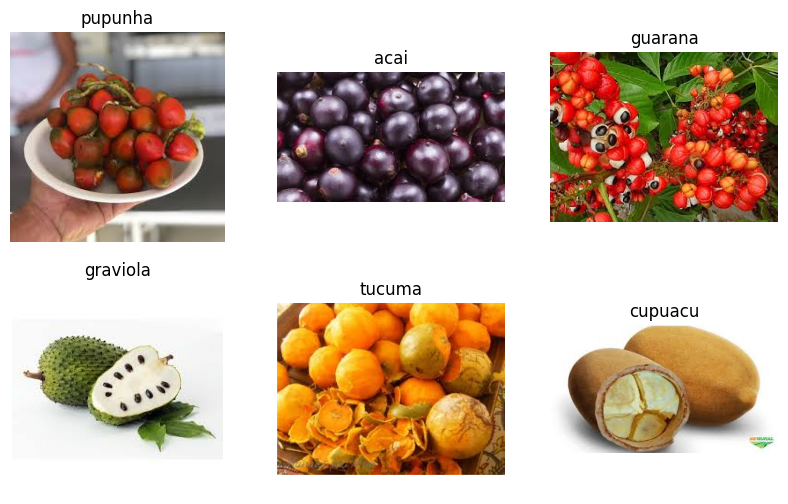

In [ ]:
import matplotlib.pyplot as plt
import random

plt.figure(figsize=(10,6))

for i, cls in enumerate(class_names[:6]):
    path = os.path.join(train_dir, cls)
    img_name = random.choice(os.listdir(path))
    img_path = os.path.join(path, img_name)

    img = plt.imread(img_path)

    plt.subplot(2,3,i+1)
    plt.imshow(img)
    plt.title(cls)
    plt.axis("off")

plt.show()

# Create Dataset

In [ ]:
import tensorflow as tf

image_size = (224,224)
batch_size = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=image_size,
    batch_size=batch_size
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=image_size,
    batch_size=batch_size
)

Found 90 files belonging to 6 classes.
Using 72 files for training.
Found 90 files belonging to 6 classes.
Using 18 files for validation.


# Data Augmentation

In [ ]:
from tensorflow.keras import layers

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
])

# Improved CNN Model (Task 1)

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.layers import BatchNormalization, Dropout, Activation


img_height = image_size[0]
img_width = image_size[1]
num_classes = len(class_names)

print("Building the CNN model...")
model = Sequential([
    # Explicitly define the input shape for the model
    keras.Input(shape=(img_height, img_width, 3)),
    # Data augmentation using the Sequential model defined in cell g97YCxz7Jadq
    data_augmentation,


    layers.Rescaling(1./255),

    # First Convolutional Block
    Conv2D(32, (3, 3), padding='same', activation=None),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    # Second Convolutional Block
    Conv2D(64, (3, 3), padding='same', activation=None),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    # Third Convolutional Block
    Conv2D(128, (3, 3), padding='same', activation=None),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    # Fourth Convolutional Block
    Conv2D(256, (3, 3), padding='same', activation=None),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    # Flatten
    Flatten(),

    # First Fully Connected Layer
    Dense(512, activation=None),
    BatchNormalization(),
    Activation('relu'),
    Dropout(0.5),

    # Second Fully Connected Layer
    Dense(256, activation=None),
    BatchNormalization(),
    Activation('relu'),
    Dropout(0.5),

    # Third Fully Connected Layer
    Dense(128, activation=None),
    BatchNormalization(),
    Activation('relu'),
    Dropout(0.5),

    # Fourth Fully Connected Layer
    Dense(64, activation=None),
    BatchNormalization(),
    Activation('relu'),
    Dropout(0.5),

    # Output Layer
    Dense(num_classes, activation='softmax')
])

model.summary()

Building the CNN model...


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_2 (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_3 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_24          │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_24 (Activation)      │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_24 (Dropout)            │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_25          │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_25 (Activation)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_25 (Dropout)            │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_26          │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_26 (Activation)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_26 (Dropout)            │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_27          │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_27 (Activation)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_27 (Dropout)            │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 50176)          │             

 Total params: 26,257,670 (100.17 MB)

 Trainable params: 26,254,790 (100.15 MB)

 Non-trainable params: 2,880 (11.25 KB)

## Task 4 – Compile Model

This task configures the model for training using the `compile` method. It specifies the optimizer (`adam`), loss function (`sparse_categorical_crossentropy`), and metrics to monitor during training (`accuracy`).

In [ ]:
print("Compiling the model...")
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
print("Model compiled successfully.")

Compiling the model...
Model compiled successfully.


## Task 4 – Train Model (with Callbacks)

This task initiates the training process for the compiled model. It includes `ModelCheckpoint` to save the best model weights based on validation accuracy and `EarlyStopping` to prevent overfitting by monitoring validation loss. Training will run for up to 250 epochs, with a batch size of 16 for the `model.fit` function.

In [ ]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

print("Starting model training...")

# Callbacks
checkpoint = ModelCheckpoint("best_model.h5", monitor='val_accuracy', save_best_only=True, verbose=1)
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1)

# Train the model
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=250,
    batch_size=16,
    callbacks=[checkpoint, early_stop]
)

print("Model training completed.")

Starting model training...
Epoch 1/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.1094 - loss: 2.4255
Epoch 1: val_accuracy improved from None to 0.38889, saving model to best_model.h5



Epoch 1: finished saving model to best_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 30s 7s/step - accuracy: 0.1250 - loss: 2.4078 - val_accuracy: 0.3889 - val_loss: 1.7624
Epoch 2/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 10s/step - accuracy: 0.1800 - loss: 2.3497 
Epoch 2: val_accuracy did not improve from 0.38889
3/3 ━━━━━━━━━━━━━━━━━━━━ 31s 11s/step - accuracy: 0.1806 - loss: 2.4079 - val_accuracy: 0.3333 - val_loss: 1.7895
Epoch 3/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.2054 - loss: 2.4815
Epoch 3: val_accuracy did not improve from 0.38889
3/3 ━━━━━━━━━━━━━━━━━━━━ 21s 6s/step - accuracy: 0.1944 - loss: 2.3574 - val_accuracy: 0.2778 - val_loss: 1.7877
Epoch 4/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.2286 - loss: 2.1881
Epoch 4: val_accuracy did not improve from 0.38889
3/3 ━━━━━━━━━━━━━━━━━━━━ 20s 6s/step - accuracy: 0.2639 - loss: 2.0917 - val_accuracy: 0.1667 - val_loss: 1.7913
Epoch 5/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.3003 - loss: 1.8397
Epoch 5: val_ac

In [ ]:
# model.save('final_model.h5')

## Plot Accuracy & Loss Graphs

This task visualizes the training and validation accuracy and loss over epochs. These plots are crucial for understanding the model's performance and identifying potential overfitting or underfitting.

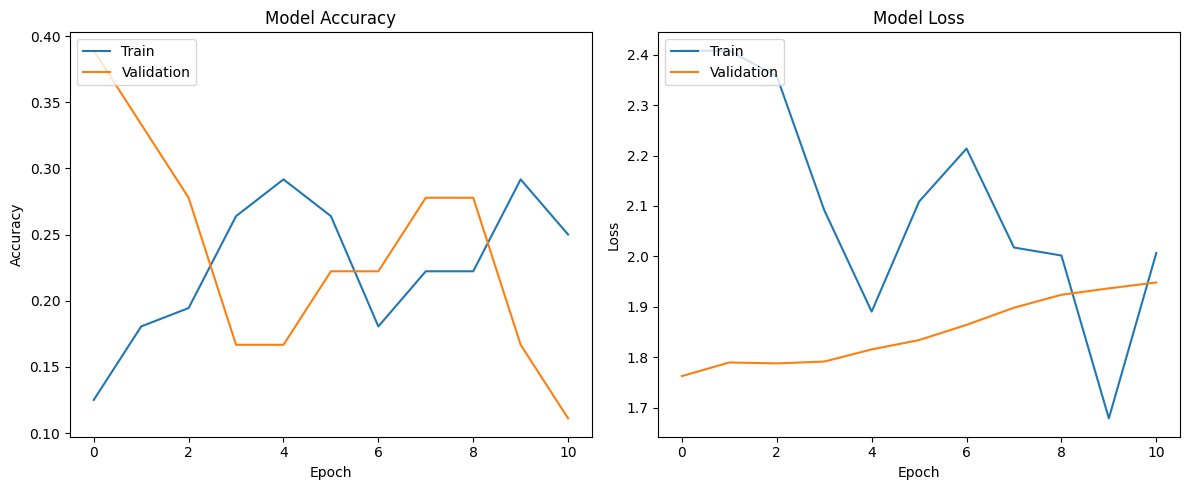

In [ ]:
import matplotlib.pyplot as plt

# Accuracy plot
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'], loc='upper left')

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.tight_layout()
plt.show()


# Task 5 – Evaluate Model

This task evaluates the trained model's performance on the validation dataset to measure its generalization capability. It prints the final loss and accuracy on the validation set.

In [ ]:
loss, acc = model.evaluate(val_ds)
print("CNN Accuracy:", acc)

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - accuracy: 0.3889 - loss: 1.7624
CNN Accuracy: 0.3888888955116272


In [ ]:
print("Evaluating the model on the validation dataset...")
loss, accuracy = model.evaluate(val_ds)
print(f"Validation Loss: {loss:.4f}")
print(f"Validation Accuracy: {accuracy:.4f}")

Evaluating the model on the validation dataset...
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 912ms/step - accuracy: 0.3889 - loss: 1.7624
Validation Loss: 1.7624
Validation Accuracy: 0.3889


# Transfer Learning (Task 2)

In [ ]:
from tensorflow.keras.applications import VGG16

base_model = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

for layer in base_model.layers:
    layer.trainable = False

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


# Add Custom Layers

In [ ]:
x = base_model.output
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.5)(x)

output = layers.Dense(len(class_names), activation='softmax')(x)

vgg_model = tf.keras.Model(inputs=base_model.input, outputs=output)

# Compile & Train VGG16

In [ ]:
vgg_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_vgg = vgg_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 68s 21s/step - accuracy: 0.1528 - loss: 12.9281 - val_accuracy: 0.2222 - val_loss: 4.2390
Epoch 2/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 71s 25s/step - accuracy: 0.1944 - loss: 8.1493 - val_accuracy: 0.2222 - val_loss: 3.1754
Epoch 3/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 87s 26s/step - accuracy: 0.4028 - loss: 4.5713 - val_accuracy: 0.5000 - val_loss: 2.2615
Epoch 4/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 71s 24s/step - accuracy: 0.5278 - loss: 2.8728 - val_accuracy: 0.5556 - val_loss: 2.1548
Epoch 5/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 81s 25s/step - accuracy: 0.7083 - loss: 1.3989 - val_accuracy: 0.5556 - val_loss: 2.2375
Epoch 6/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 82s 25s/step - accuracy: 0.8194 - loss: 0.8063 - val_accuracy: 0.6111 - val_loss: 2.3251
Epoch 7/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 82s 24s/step - accuracy: 0.8056 - loss: 1.0202 - val_accuracy: 0.7778 - val_loss: 2.2919
Epoch 8/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 82s 23s/step - accuracy: 0.8056 - loss: 0.9411 - val_accuracy: 0.6667 - val_loss: 2.2379

# Evaluate VGG16

In [ ]:
loss_vgg, acc_vgg = vgg_model.evaluate(val_ds)
print("VGG16 Accuracy:", acc_vgg)

1/1 ━━━━━━━━━━━━━━━━━━━━ 12s 12s/step - accuracy: 0.6111 - loss: 2.1298
VGG16 Accuracy: 0.6111111044883728


# Classification Report

In [ ]:
from sklearn.metrics import classification_report
import numpy as np

y_true = []
y_pred = []

for images, labels in val_ds:
    preds = vgg_model.predict(images)
    preds = np.argmax(preds, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(preds)

print(classification_report(y_true, y_pred))

1/1 ━━━━━━━━━━━━━━━━━━━━ 21s 21s/step
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       0.50      0.50      0.50         2
           2       0.75      1.00      0.86         3
           3       1.00      0.60      0.75         5
           4       0.50      0.50      0.50         4
           5       0.40      0.67      0.50         3

    accuracy                           0.61        18
   macro avg       0.53      0.54      0.52        18
weighted avg       0.64      0.61      0.60        18



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


# Final Comparison

In [ ]:
print("CNN Accuracy:", acc)
print("VGG16 Accuracy:", acc_vgg)

CNN Accuracy: 0.3888888955116272
VGG16 Accuracy: 0.6111111044883728
